# ============= IMPORTAR LIBRERÍAS ==============

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import joblib
import sklearn

from scipy.stats import spearmanr

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit


In [2]:
def audit_missing(df: pd.DataFrame) -> pd.DataFrame:
    return (
        pd.DataFrame({
            "dtype": df.dtypes.astype(str),
            "n_missing": df.isna().sum(),
            "pct_missing": (df.isna().mean() * 100).round(2),
            "n_unique": df.nunique(dropna=True)
        })
        .sort_values("pct_missing", ascending=False)
    )

def to_datetime_safe(s: pd.Series, fmt: str | None = None) -> pd.Series:
    return pd.to_datetime(s, errors="coerce", format=fmt)

def pct_to_num(s: pd.Series) -> pd.Series:
    # Convierte "85%" -> 85, y valores raros -> NaN
    return pd.to_numeric(s.astype(str).str.replace("%", "", regex=False), errors="coerce")

def fmt_min_to_hm(minutes: float) -> str:
    if minutes is None or (isinstance(minutes, float) and np.isnan(minutes)):
        return "NA"
    m = int(round(float(minutes)))
    h = m // 60
    mm = m % 60
    return f"{h}h {mm:02d}m"

def spearman_pair(df: pd.DataFrame, x: str, y: str) -> dict:
    tmp = df[[x, y]].dropna()
    r, p = spearmanr(tmp[x], tmp[y])
    return {"n": int(tmp.shape[0]), "spearman_r": float(r), "p_value": float(p)}

def conformal_q(errs, alpha):
    errs = np.asarray(errs, dtype=float)
    errs = errs[np.isfinite(errs)]
    n = len(errs)
    if n == 0:
        return np.nan

    level = np.ceil((n + 1) * (1 - alpha)) / n
    level = min(level, 1.0)
    return float(np.quantile(errs, level))

def make_ridge_pipeline(num_cols: list[str], cat_cols: list[str], alpha: float) -> Pipeline:
    preprocess = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), num_cols),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]), cat_cols),
        ]
    )

    return Pipeline(steps=[
        ("prep", preprocess),
        ("model", Ridge(alpha=alpha, random_state=0))
    ])


# ============= CARGAR DATASET ==============

In [3]:
DATA_PATH = Path('C://Users//mitev//Desktop//Prácticas/SLEEP_CYCLE_PROYECT/dataset/My complete sleep data.csv')  # cambia la ruta si guardas el CSV en otra carpeta
df_raw = pd.read_csv(DATA_PATH, sep=";")

print(f"Dataset cargado desde: {DATA_PATH.resolve()}")
df_raw.head()


Dataset cargado desde: C:\Users\mitev\Desktop\Prácticas\SLEEP_CYCLE_PROYECT\dataset\My complete sleep data.csv


,Went to bed,Woke up,Sleep Quality,Time in bed (seconds),Time asleep (seconds),Asleep after (seconds),Regularity,Did snore,Snore time (seconds),Not my snoring (seconds),...,Breathing disruptions (per hour),Ambient noise (dB),Ambient light (lux),Alertness score,Alertness reaction time (seconds),Alertness accuracy,Movements per hour,Wake up window start,Wake up window stop,Notes
0,2025-01-25 22:51:43,2025-01-26 07:08:14,85%,29790,22938,595,—,False,0,0,...,0.0,32.148480,0.0625,NaN,NaN,NaN,46.916313,NaN,NaN,NaN
1,2025-01-26 23:00:04,2025-01-27 01:38:08,27%,9484,6322,189,53%,False,0,0,...,0.0,32.735294,0.0000,NaN,NaN,NaN,45.508270,NaN,NaN,NaN
2,2025-01-27 02:49:25,2025-01-27 08:36:38,25%,20832,16735,416,53%,False,0,0,...,0.0,32.228764,0.0625,NaN,NaN,NaN,74.894710,NaN,NaN,NaN
3,2025-01-28 00:48:09,2025-01-28 08:33:46,82%,27936,18810,558,40%,False,0,0,...,0.0,32.166110,0.0000,NaN,NaN,NaN,52.669544,NaN,NaN,NaN
4,2025-01-29 23:17:38,2025-01-30 07:30:11,91%,29553,22558,591,53%,False,0,0,...,0.0,32.966760,0.0000,NaN,NaN,NaN,47.623844,NaN,NaN,NaN


# ======== DATA PREPARATION =========

In [4]:
audit = audit_missing(df_raw)

# Drop columnas con >= 90% nulos
cols_drop_90 = audit.index[audit["pct_missing"] >= 90].tolist()
df_1 = df_raw.drop(columns=cols_drop_90).copy()

# Drop columnas con muy poca información útil
low_info_cols = [c for c in df_1.columns if df_1[c].nunique(dropna=True) <= 1]
df_1 = df_1.drop(columns=low_info_cols).copy()

print("shape original:", df_raw.shape)
print("shape tras drop >=90% nulos:", df_1.shape)
print("columnas eliminadas por nulos:", cols_drop_90)
print("columnas eliminadas por baja información:", low_info_cols)

audit_after = audit_missing(df_1)
audit_after.head(12)


shape original: (310, 26)
shape tras drop >=90% nulos: (310, 20)
columnas eliminadas por nulos: ['Alertness accuracy', 'Alertness reaction time (seconds)', 'Alertness score', 'Notes']
columnas eliminadas por baja información: ['Steps', 'City']


,dtype,n_missing,pct_missing,n_unique
Air Pressure (Pa),float64,276,89.03,30
Weather temperature (°C),float64,156,50.32,13
Weather type,object,156,50.32,5
Wake up window start,object,47,15.16,262
Wake up window stop,object,47,15.16,262
Ambient light (lux),float64,2,0.65,11
Ambient noise (dB),float64,2,0.65,308
Breathing disruptions (per hour),float64,1,0.32,21
Time in bed (seconds),int64,0,0.00,304
Sleep Quality,object,0,0.00,61


In [5]:
df_2 = df_1.copy()

# Fechas principales
if "Went to bed" in df_2.columns:
    df_2["Went to bed"] = to_datetime_safe(df_2["Went to bed"])
if "Woke up" in df_2.columns:
    df_2["Woke up"] = to_datetime_safe(df_2["Woke up"])

# Wake up window con año en 2 dígitos (si existe)
for c in ["Wake up window start", "Wake up window stop"]:
    if c in df_2.columns:
        df_2[c] = to_datetime_safe(df_2[c], fmt="%y-%m-%d %H:%M:%S")

# Porcentajes
if "Sleep Quality" in df_2.columns:
    df_2["Sleep Quality"] = pct_to_num(df_2["Sleep Quality"])

if "Regularity" in df_2.columns:
    df_2["Regularity"] = df_2["Regularity"].replace("—", np.nan)
    df_2["Regularity"] = pct_to_num(df_2["Regularity"])

# Corregir placeholder de Woke up: 1969-12-31 23:59:59 -> NaT
placeholder_woke = pd.Timestamp("1969-12-31 23:59:59")
df_2["flag_woke_placeholder_fixed"] = False
if "Woke up" in df_2.columns:
    df_2["flag_woke_placeholder_fixed"] = df_2["Woke up"].eq(placeholder_woke)
    df_2.loc[df_2["flag_woke_placeholder_fixed"], "Woke up"] = pd.NaT

# Eliminar duplicados por "Went to bed" conservando la fila más informativa
n_dups_removed = 0
if "Went to bed" in df_2.columns:
    sort_cols = [c for c in ["Went to bed", "Time in bed (seconds)", "Time asleep (seconds)"] if c in df_2.columns]
    ascending = [True] + [False] * (len(sort_cols) - 1)

    n_before = len(df_2)
    df_2 = (
        df_2.sort_values(sort_cols, ascending=ascending)
            .drop_duplicates(subset=["Went to bed"], keep="first")
            .copy()
    )
    n_dups_removed = n_before - len(df_2)

# Duración calculada por timestamps
df_2["in_bed_seconds_calc"] = np.nan
if "Went to bed" in df_2.columns and "Woke up" in df_2.columns:
    df_2["in_bed_seconds_calc"] = (df_2["Woke up"] - df_2["Went to bed"]).dt.total_seconds()

# Comparación con la métrica de la app si existe
df_2["flag_inbed_mismatch_10min"] = False
if "Time in bed (seconds)" in df_2.columns:
    df_2["in_bed_diff"] = df_2["in_bed_seconds_calc"] - df_2["Time in bed (seconds)"]
    df_2["flag_inbed_mismatch_10min"] = df_2["in_bed_diff"].abs() > 600
else:
    df_2["in_bed_diff"] = np.nan

# Decisión: time_in_bed_final = Time in bed (seconds) como referencia y calc como fallback
if "Time in bed (seconds)" in df_2.columns:
    df_2["time_in_bed_final"] = df_2["Time in bed (seconds)"].where(
        df_2["Time in bed (seconds)"].notna(),
        df_2["in_bed_seconds_calc"]
    )
else:
    df_2["time_in_bed_final"] = df_2["in_bed_seconds_calc"]

# Flag: sesión sin sueño real (asleep=0 con tiempo en cama >0)
df_2["flag_no_sleep_session"] = False
if "Time asleep (seconds)" in df_2.columns:
    df_2["flag_no_sleep_session"] = (
        df_2["Time asleep (seconds)"].fillna(-1).eq(0)
        & df_2["time_in_bed_final"].notna()
        & (df_2["time_in_bed_final"] > 0)
    )

# Métricas en minutos + eficiencia
df_2["time_in_bed_min"] = df_2["time_in_bed_final"] / 60
df_2["time_asleep_min"] = np.nan
df_2["sleep_efficiency_pct"] = np.nan
if "Time asleep (seconds)" in df_2.columns:
    denom = df_2["time_in_bed_final"].replace(0, np.nan)
    df_2["time_asleep_min"] = df_2["Time asleep (seconds)"] / 60
    df_2["sleep_efficiency_pct"] = (df_2["Time asleep (seconds)"] / denom) * 100

# Componentes: latencia y tiempo despierto en cama
df_2["latency_min"] = np.nan
if "Asleep after (seconds)" in df_2.columns:
    df_2["latency_min"] = df_2["Asleep after (seconds)"] / 60

df_2["awake_in_bed_min"] = np.nan
if "Time asleep (seconds)" in df_2.columns:
    df_2["awake_in_bed_min"] = ((df_2["time_in_bed_final"] - df_2["Time asleep (seconds)"]) / 60).clip(lower=0)

# Dataset para EDA principal: sesiones con sueño real y tiempo en cama válido
df_sleep = df_2[
    (df_2["Time asleep (seconds)"].fillna(0) > 0)
    & (df_2["time_in_bed_final"].fillna(0) > 0)
].copy()

# Outliers de duración
df_sleep["flag_outlier_high"] = (df_sleep["time_asleep_min"] > 900) | (df_sleep["time_in_bed_min"] > 1000)
df_sleep["flag_outlier_low"] = (df_sleep["time_asleep_min"] < 180)

# Dataset principal sin outliers altos
df_sleep_main = df_sleep.loc[~df_sleep["flag_outlier_high"]].copy()

print("placeholder corregidos:", int(df_2["flag_woke_placeholder_fixed"].sum()))
print("duplicados eliminados por Went to bed:", n_dups_removed)
print("mismatch >10min:", int(df_2["flag_inbed_mismatch_10min"].sum()))
print("no sleep sessions:", int(df_2["flag_no_sleep_session"].sum()))
print("df_sleep:", df_sleep.shape, "outliers_high:", int(df_sleep["flag_outlier_high"].sum()))
print("df_sleep_main:", df_sleep_main.shape)


placeholder corregidos: 0
duplicados eliminados por Went to bed: 1
mismatch >10min: 1
no sleep sessions: 1
df_sleep: (308, 33) outliers_high: 2
df_sleep_main: (306, 33)


In [6]:
cols_final = [
    "Went to bed", "Woke up",
    "Sleep Quality", "Regularity",
    "time_asleep_min", "time_in_bed_min",
    "sleep_efficiency_pct", "latency_min", "awake_in_bed_min",
    "flag_outlier_high", "flag_outlier_low", "flag_no_sleep_session"
]
cols_final = [c for c in cols_final if c in df_sleep_main.columns]

df_final = df_sleep_main[cols_final].copy()

df_analysis = df_final.copy()
df_analysis.loc[df_analysis["Regularity"].eq(0), "Regularity"] = pd.NA

print("df_final:", df_final.shape)
df_final.head()

df_final: (306, 12)


,Went to bed,Woke up,Sleep Quality,Regularity,time_asleep_min,time_in_bed_min,sleep_efficiency_pct,latency_min,awake_in_bed_min,flag_outlier_high,flag_outlier_low,flag_no_sleep_session
0,2025-01-25 22:51:43,2025-01-26 07:08:14,85,NaN,382.300000,496.500000,76.998993,9.916667,114.200000,False,False,False
1,2025-01-26 23:00:04,2025-01-27 01:38:08,27,53.0,105.366667,158.066667,66.659637,3.150000,52.700000,False,True,False
2,2025-01-27 02:49:25,2025-01-27 08:36:38,25,53.0,278.916667,347.200000,80.333141,6.933333,68.283333,False,False,False
3,2025-01-28 00:48:09,2025-01-28 08:33:46,82,40.0,313.500000,465.600000,67.332474,9.300000,152.100000,False,False,False
4,2025-01-29 23:17:38,2025-01-30 07:30:11,91,53.0,375.966667,492.550000,76.330660,9.850000,116.583333,False,False,False


# ================== EDA ===================

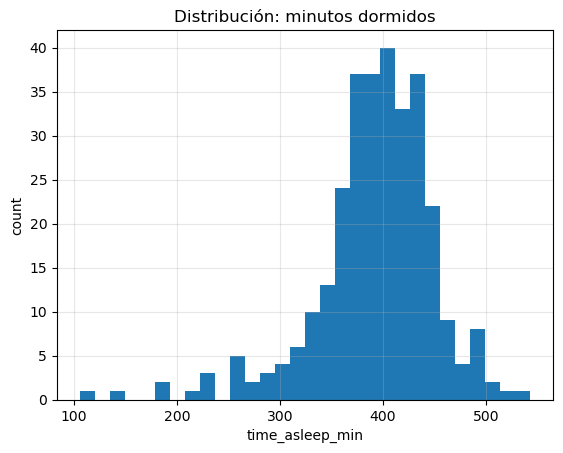

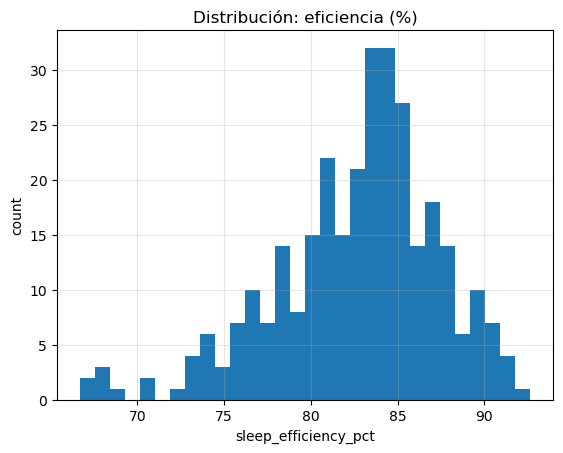

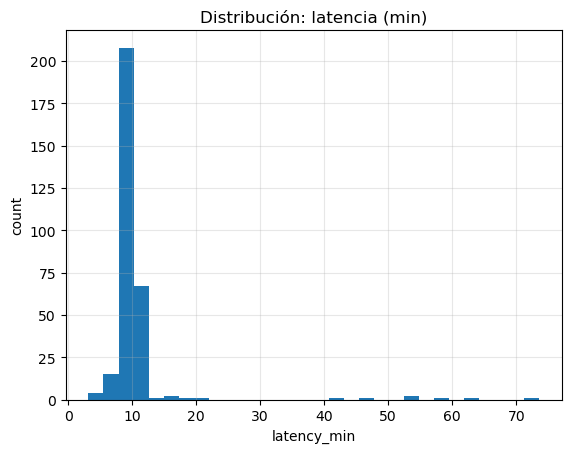

In [7]:
plt.figure()
df_analysis["time_asleep_min"].dropna().hist(bins=30)
plt.title("Distribución: minutos dormidos")
plt.xlabel("time_asleep_min")
plt.ylabel("count")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure()
df_analysis["sleep_efficiency_pct"].dropna().hist(bins=30)
plt.title("Distribución: eficiencia (%)")
plt.xlabel("sleep_efficiency_pct")
plt.ylabel("count")
plt.grid(True, alpha=0.3)
plt.show()

if df_analysis["latency_min"].notna().any():
    plt.figure()
    df_analysis["latency_min"].dropna().hist(bins=30)
    plt.title("Distribución: latencia (min)")
    plt.xlabel("latency_min")
    plt.ylabel("count")
    plt.grid(True, alpha=0.3)
    plt.show()

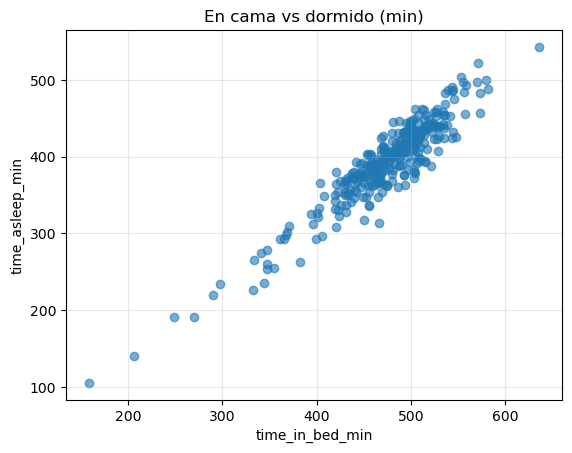

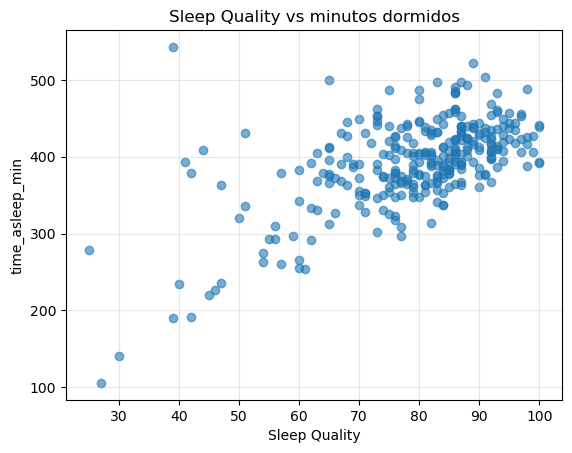

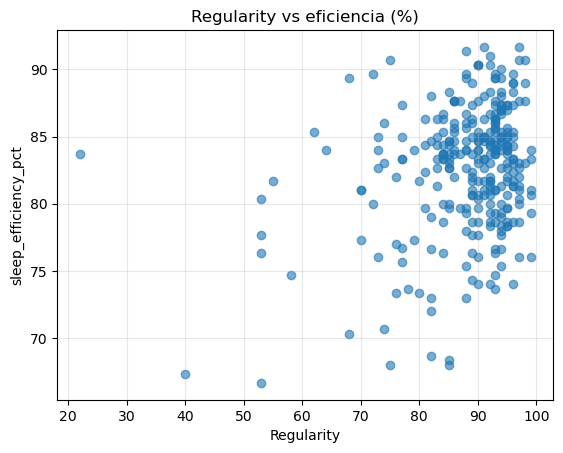

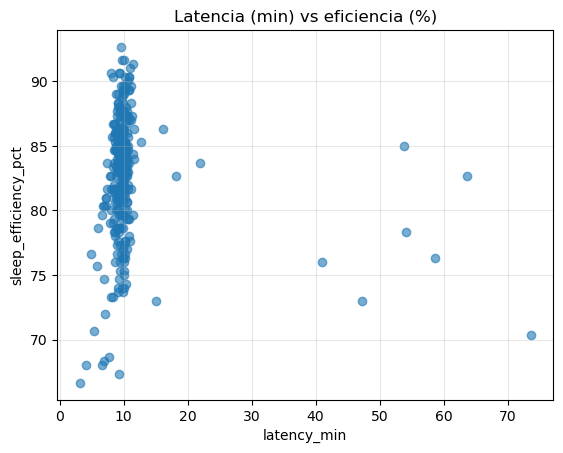

In [8]:
plt.figure()
plt.scatter(df_analysis["time_in_bed_min"], df_analysis["time_asleep_min"], alpha=0.6)
plt.title("En cama vs dormido (min)")
plt.xlabel("time_in_bed_min")
plt.ylabel("time_asleep_min")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure()
plt.scatter(df_analysis["Sleep Quality"], df_analysis["time_asleep_min"], alpha=0.6)
plt.title("Sleep Quality vs minutos dormidos")
plt.xlabel("Sleep Quality")
plt.ylabel("time_asleep_min")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure()
plt.scatter(df_analysis["Regularity"], df_analysis["sleep_efficiency_pct"], alpha=0.6)
plt.title("Regularity vs eficiencia (%)")
plt.xlabel("Regularity")
plt.ylabel("sleep_efficiency_pct")
plt.grid(True, alpha=0.3)
plt.show()

if df_analysis["latency_min"].notna().any():
    plt.figure()
    plt.scatter(df_analysis["latency_min"], df_analysis["sleep_efficiency_pct"], alpha=0.6)
    plt.title("Latencia (min) vs eficiencia (%)")
    plt.xlabel("latency_min")
    plt.ylabel("sleep_efficiency_pct")
    plt.grid(True, alpha=0.3)
    plt.show()

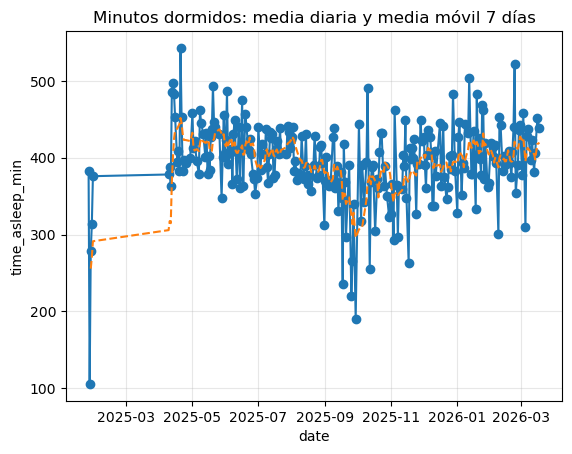

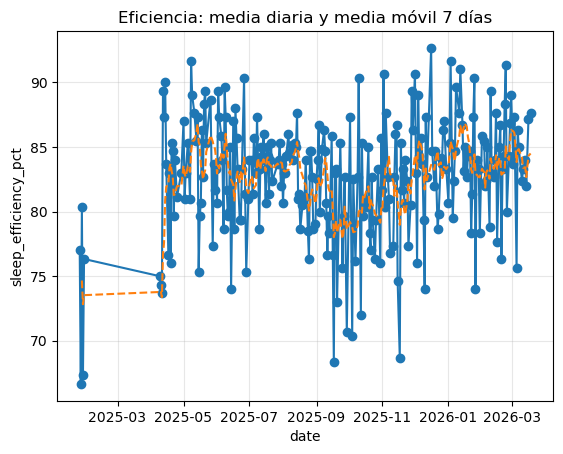

In [9]:
df_ts = df_analysis.dropna(subset=["Went to bed"]).copy()
df_ts["date"] = df_ts["Went to bed"].dt.date
daily = (
    df_ts.groupby("date", observed=True)
    .agg(
        asleep_mean=("time_asleep_min", "mean"),
        eff_mean=("sleep_efficiency_pct", "mean"),
        n=("time_asleep_min", "size")
    )
    .reset_index()
)

daily["date"] = pd.to_datetime(daily["date"])
daily = daily.sort_values("date")
daily["asleep_7d"] = daily["asleep_mean"].rolling(7, min_periods=3).mean()
daily["eff_7d"] = daily["eff_mean"].rolling(7, min_periods=3).mean()

plt.figure()
plt.plot(daily["date"], daily["asleep_mean"], marker="o", linestyle="-")
plt.plot(daily["date"], daily["asleep_7d"], linestyle="--")
plt.title("Minutos dormidos: media diaria y media móvil 7 días")
plt.xlabel("date")
plt.ylabel("time_asleep_min")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure()
plt.plot(daily["date"], daily["eff_mean"], marker="o", linestyle="-")
plt.plot(daily["date"], daily["eff_7d"], linestyle="--")
plt.title("Eficiencia: media diaria y media móvil 7 días")
plt.xlabel("date")
plt.ylabel("sleep_efficiency_pct")
plt.grid(True, alpha=0.3)
plt.show()

Spearman Sleep Quality vs time_asleep_min: {'n': 306, 'spearman_r': 0.5143208810664064, 'p_value': 4.605611301959665e-22}
Spearman Sleep Quality vs efficiency: {'n': 306, 'spearman_r': 0.10164020263550204, 'p_value': 0.07584821419210645}
Spearman Regularity vs time_asleep_min (sin reg=0): {'n': 298, 'spearman_r': 0.15819884324296438, 'p_value': 0.006205652013261139}
Spearman Regularity vs efficiency (sin reg=0): {'n': 298, 'spearman_r': 0.15885383101345527, 'p_value': 0.005992546791026602}


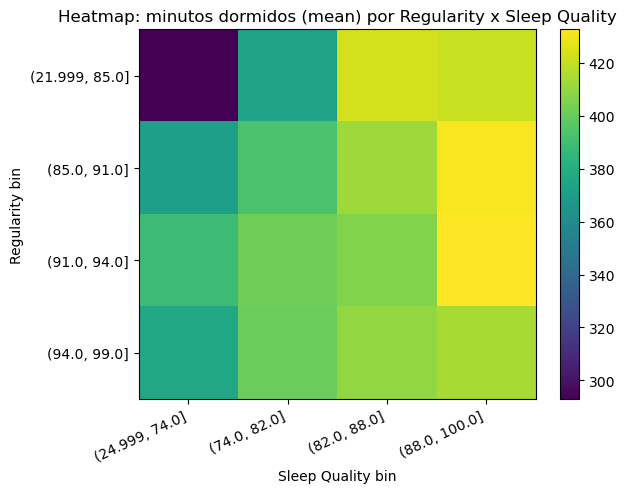

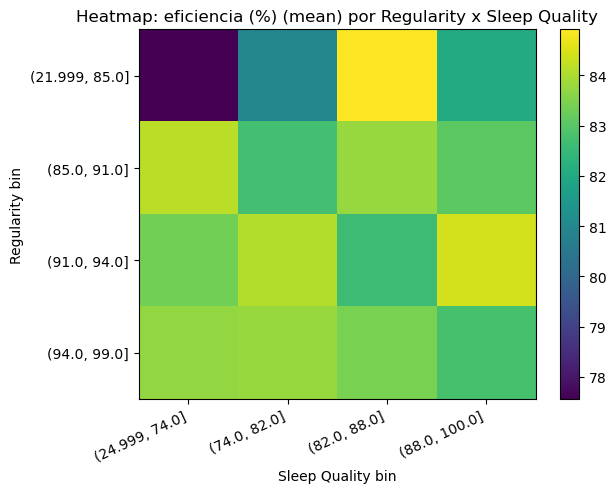

(          reg_bin   n  asleep_mean   eff_mean
 0  (21.999, 85.0]  82   364.802642  80.637517
 1    (85.0, 91.0]  77   400.074675  83.466744
 2    (91.0, 94.0]  77   406.412771  83.466763
 3    (94.0, 99.0]  62   403.370430  83.364979,
            sq_bin   n  asleep_mean   eff_mean
 0  (24.999, 74.0]  78   348.117308  81.542094
 1    (74.0, 82.0]  74   390.974550  82.710996
 2    (82.0, 88.0]  77   411.413853  83.475316
 3   (88.0, 100.0]  69   424.031643  82.989692)

In [10]:
df_b = df_analysis.copy()
df_b.loc[df_b["Regularity"].eq(0), "Regularity"] = pd.NA
df_b = df_b.dropna(subset=["Regularity", "Sleep Quality", "time_asleep_min", "sleep_efficiency_pct"]).copy()

# Bins por cuantiles
df_b["reg_bin"] = pd.qcut(df_b["Regularity"], q=4, duplicates="drop")
df_b["sq_bin"] = pd.qcut(df_b["Sleep Quality"], q=4, duplicates="drop")

summary_reg = df_b.groupby("reg_bin", observed=True).agg(
    n=("Regularity", "size"),
    asleep_mean=("time_asleep_min", "mean"),
    eff_mean=("sleep_efficiency_pct", "mean"),
).reset_index()

summary_sq = df_b.groupby("sq_bin", observed=True).agg(
    n=("Sleep Quality", "size"),
    asleep_mean=("time_asleep_min", "mean"),
    eff_mean=("sleep_efficiency_pct", "mean"),
).reset_index()

tab2d = df_b.groupby(["reg_bin", "sq_bin"], observed=True).agg(
    n=("time_asleep_min", "size"),
    asleep_mean=("time_asleep_min", "mean"),
    eff_mean=("sleep_efficiency_pct", "mean"),
).reset_index()

pivot_asleep = tab2d.pivot(index="reg_bin", columns="sq_bin", values="asleep_mean")
pivot_eff = tab2d.pivot(index="reg_bin", columns="sq_bin", values="eff_mean")

print("Spearman Sleep Quality vs time_asleep_min:", spearman_pair(df_analysis, "Sleep Quality", "time_asleep_min"))
print("Spearman Sleep Quality vs efficiency:", spearman_pair(df_analysis, "Sleep Quality", "sleep_efficiency_pct"))

print("Spearman Regularity vs time_asleep_min (sin reg=0):", spearman_pair(df_b, "Regularity", "time_asleep_min"))
print("Spearman Regularity vs efficiency (sin reg=0):", spearman_pair(df_b, "Regularity", "sleep_efficiency_pct"))

# Heatmap minutos
plt.figure()
plt.imshow(pivot_asleep.values, aspect="auto")
plt.title("Heatmap: minutos dormidos (mean) por Regularity x Sleep Quality")
plt.xlabel("Sleep Quality bin")
plt.ylabel("Regularity bin")
plt.xticks(range(pivot_asleep.shape[1]), [str(c) for c in pivot_asleep.columns], rotation=25, ha="right")
plt.yticks(range(pivot_asleep.shape[0]), [str(i) for i in pivot_asleep.index])
plt.colorbar()
plt.show()

# Heatmap eficiencia
plt.figure()
plt.imshow(pivot_eff.values, aspect="auto")
plt.title("Heatmap: eficiencia (%) (mean) por Regularity x Sleep Quality")
plt.xlabel("Sleep Quality bin")
plt.ylabel("Regularity bin")
plt.xticks(range(pivot_eff.shape[1]), [str(c) for c in pivot_eff.columns], rotation=25, ha="right")
plt.yticks(range(pivot_eff.shape[0]), [str(i) for i in pivot_eff.index])
plt.colorbar()
plt.show()

summary_reg, summary_sq

# =============== MODELADO ================

In [11]:
df_m = df_analysis.dropna(subset=["Went to bed", "time_asleep_min"]).copy()
df_m = df_m.sort_values("Went to bed")

# Calendario y bed_hour (los lags/rolling usan solo pasado)
df_m["weekday"] = df_m["Went to bed"].dt.day_name()
df_m["month"] = df_m["Went to bed"].dt.month
df_m["bed_hour"] = (
    df_m["Went to bed"].dt.hour
    + df_m["Went to bed"].dt.minute / 60
    + df_m["Went to bed"].dt.second / 3600
)

target = "time_asleep_min"
base_cols = [target, "sleep_efficiency_pct", "latency_min", "bed_hour", "Regularity"]
base_cols = [c for c in base_cols if c in df_m.columns]

# Lags + rolling7 solo con pasado
for col in base_cols:
    df_m[f"{col}_lag1"] = df_m[col].shift(1)
    df_m[f"{col}_roll7"] = df_m[col].shift(1).rolling(7, min_periods=3).mean()

feature_cols = ["weekday", "month"] + [f"{c}_lag1" for c in base_cols] + [f"{c}_roll7" for c in base_cols]
feature_cols = [c for c in feature_cols if c in df_m.columns]

df_model = df_m.dropna(subset=[target, f"{target}_lag1"]).copy()

# Split temporal 80/20 para evaluación final
cut = int(len(df_model) * 0.8)
train = df_model.iloc[:cut].copy()
test = df_model.iloc[cut:].copy()

X_train, y_train = train[feature_cols], train[target]
X_test, y_test = test[feature_cols], test[target]

# Baselines
mae_last = mean_absolute_error(y_test, test[f"{target}_lag1"])
mae_roll7 = mean_absolute_error(y_test, test[f"{target}_roll7"])

# Columnas para el pipeline
cat_cols = [c for c in ["weekday"] if c in feature_cols]
num_cols = [c for c in feature_cols if c not in cat_cols]

# Búsqueda de alpha con validación temporal
alphas = [0.1, 1, 10, 30, 100, 300, 1000, 3000, 10000]
tscv = TimeSeriesSplit(n_splits=5)

cv_rows = []
for alpha_candidate in alphas:
    fold_maes = []
    for tr_idx, val_idx in tscv.split(train):
        tr_fold = train.iloc[tr_idx].copy()
        val_fold = train.iloc[val_idx].copy()

        X_tr, y_tr = tr_fold[feature_cols], tr_fold[target]
        X_val, y_val = val_fold[feature_cols], val_fold[target]

        fold_model = make_ridge_pipeline(num_cols=num_cols, cat_cols=cat_cols, alpha=alpha_candidate)
        fold_model.fit(X_tr, y_tr)
        pred_val = fold_model.predict(X_val)

        fold_maes.append(mean_absolute_error(y_val, pred_val))

    cv_rows.append({
        "alpha": alpha_candidate,
        "cv_mae_mean": float(np.mean(fold_maes)),
        "cv_mae_std": float(np.std(fold_maes))
    })

cv_results = pd.DataFrame(cv_rows).sort_values("cv_mae_mean").reset_index(drop=True)
best_alpha = float(cv_results.loc[0, "alpha"])

# Modelo final de evaluación sobre holdout
model = make_ridge_pipeline(num_cols=num_cols, cat_cols=cat_cols, alpha=best_alpha)
model.fit(X_train, y_train)
pred_test = model.predict(X_test)

mae_ridge = mean_absolute_error(y_test, pred_test)

print("MAE baseline last:", round(mae_last, 3))
print("MAE baseline roll7:", round(mae_roll7, 3))
print("MAE Ridge:", round(mae_ridge, 3))
print("Best alpha (CV temporal):", best_alpha)
print()
print(cv_results)

# Intervalos conformal 90% usando errores recientes del train
pred_train = model.predict(X_train)
abs_err_train = np.abs(y_train.values - pred_train)

W = 60
alpha = 0.10  # 90%
history_errs = abs_err_train[-min(W, len(abs_err_train)):]

q = conformal_q(history_errs, alpha)
low = pred_test - q
high = pred_test + q

coverage = float(np.mean((y_test.values >= low) & (y_test.values <= high)))
avg_width = float(np.mean(high - low))

print()
print("Cobertura empírica (objetivo 90%):", round(coverage, 3))
print("Ancho medio intervalo (min):", round(avg_width, 3), "half-width q:", round(q, 3))

test_pred = test.copy()
test_pred["pred"] = pred_test
test_pred["low_90"] = low
test_pred["high_90"] = high
test_pred["abs_err"] = np.abs(test_pred[target].values - test_pred["pred"].values)

test_pred[["Went to bed", target, "pred", "low_90", "high_90", "abs_err"]].head(10)


MAE baseline last: 60.961
MAE baseline roll7: 42.813
MAE Ridge: 41.139
Best alpha (CV temporal): 3000.0

     alpha  cv_mae_mean  cv_mae_std
0   3000.0    40.678951   12.170513
1  10000.0    40.728020   12.168966
2   1000.0    40.782945   12.163870
3    300.0    42.296397   12.922451
4    100.0    44.427851   13.555960
5     30.0    46.801960   10.189645
6     10.0    51.285201    8.587668
7      1.0    65.815837   21.319379
8      0.1    74.315893   26.530745

Cobertura empírica (objetivo 90%): 0.918
Ancho medio intervalo (min): 190.418 half-width q: 95.209


,Went to bed,time_asleep_min,pred,low_90,high_90,abs_err
248,2026-01-14 00:07:16,378.883333,394.887215,299.678112,490.096318,16.003882
249,2026-01-15 00:21:43,342.133333,393.845977,298.636874,489.055081,51.712644
250,2026-01-15 23:11:04,415.966667,392.927931,297.718827,488.137034,23.038736
251,2026-01-16 22:49:50,434.300000,394.033290,298.824187,489.242393,40.266710
252,2026-01-18 00:37:44,332.866667,394.487760,299.278657,489.696863,61.621093
253,2026-01-19 22:32:30,483.100000,392.122110,296.913007,487.331213,90.977890
254,2026-01-20 23:21:42,405.516667,393.391416,298.182313,488.600519,12.125251
255,2026-01-21 22:57:53,425.900000,392.151342,296.942239,487.360445,33.748658
256,2026-01-22 22:52:33,397.983333,393.275076,298.065973,488.484180,4.708257
258,2026-01-23 23:36:16,378.000000,392.374535,297.165432,487.583638,14.374535


In [12]:
coef_model = make_ridge_pipeline(num_cols=num_cols, cat_cols=cat_cols, alpha=best_alpha)
coef_model.fit(X_train, y_train)

feature_names = coef_model.named_steps["prep"].get_feature_names_out()
coefs = coef_model.named_steps["model"].coef_

coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()

coef_df.sort_values("abs_coef", ascending=False).head(20)


,feature,coef,abs_coef
6,num__time_asleep_min_roll7,0.967992,0.967992
8,num__latency_min_roll7,-0.820885,0.820885
9,num__bed_hour_roll7,0.592935,0.592935
0,num__month,-0.545250,0.545250
7,num__sleep_efficiency_pct_roll7,0.489636,0.489636
1,num__time_asleep_min_lag1,0.455910,0.455910
5,num__Regularity_lag1,0.306031,0.306031
2,num__sleep_efficiency_pct_lag1,0.259286,0.259286
3,num__latency_min_lag1,0.152868,0.152868
13,cat__weekday_Saturday,-0.105045,0.105045


In [13]:
# Reentrenar con todo el histórico disponible para usar el modelo final
X_all = df_model[feature_cols]
y_all = df_model[target]

final_model = make_ridge_pipeline(num_cols=num_cols, cat_cols=cat_cols, alpha=best_alpha)
final_model.fit(X_all, y_all)

def predict_next_night(
    df_history: pd.DataFrame,
    model_pipeline,
    feature_cols: list[str],
    target_col="time_asleep_min",
    W=60,
    alpha=0.10,
    next_date=None
):
    df_h = df_history.sort_values("Went to bed").copy()

    last_dt = df_h["Went to bed"].iloc[-1]
    if next_date is None:
        next_date = (pd.Timestamp(last_dt).normalize() + pd.Timedelta(days=1))

    next_weekday = pd.Timestamp(next_date).day_name()
    next_month = int(pd.Timestamp(next_date).month)

    last_row = df_h.iloc[-1]
    x_next = {}
    for c in feature_cols:
        if c == "weekday":
            x_next[c] = next_weekday
        elif c == "month":
            x_next[c] = next_month
        else:
            x_next[c] = last_row.get(c, np.nan)

    X_next = pd.DataFrame([x_next])
    pred = float(model_pipeline.predict(X_next)[0])

    # errores para conformal usando el histórico disponible
    need_cols = ["Went to bed", target_col] + feature_cols
    df_for_err = df_h.dropna(subset=[c for c in need_cols if c in df_h.columns]).copy()
    X_hist = df_for_err[feature_cols]
    y_hist = df_for_err[target_col].values
    pred_hist = model_pipeline.predict(X_hist)
    abs_err = np.abs(y_hist - pred_hist)
    abs_err_window = abs_err[-min(W, len(abs_err)):]
    q = conformal_q(abs_err_window, alpha)

    return {
        "next_date": pd.Timestamp(next_date),
        "next_weekday": next_weekday,
        "next_month": next_month,
        "pred": pred,
        "low": pred - q,
        "high": pred + q,
        "interval_level": 1 - alpha,
        "half_width_q": q
    }

def pretty_sleep_forecast(result: dict, short_threshold_min: int = 360) -> dict:
    pred = result["pred"]
    low = result["low"]
    high = result["high"]

    out = {
        "date": str(result["next_date"].date()),
        "weekday": result["next_weekday"],
        "pred_min": pred,
        "low_min": low,
        "high_min": high,
        "pred_hm": fmt_min_to_hm(pred),
        "low_hm": fmt_min_to_hm(low),
        "high_hm": fmt_min_to_hm(high),
        "interval_level": result["interval_level"],
        "half_width_min": result["half_width_q"],
        "half_width_hm": fmt_min_to_hm(result["half_width_q"]),
        "flag_risk_short_sleep": bool(pred < short_threshold_min),
        "short_threshold_hm": fmt_min_to_hm(short_threshold_min),
    }
    return out

# Ejemplo real: predecir la próxima noche usando el modelo final reentrenado
result = predict_next_night(
    df_history=df_model,
    model_pipeline=final_model,
    feature_cols=feature_cols,
    target_col=target,
    W=W,
    alpha=alpha
)
report = pretty_sleep_forecast(result, short_threshold_min=360)

print(f"Predicción próxima noche ({report['date']} - {report['weekday']}):")
print(f"- Sueño esperado: {report['pred_hm']} ({report['pred_min']:.1f} min)")
print(f"- Intervalo {int(report['interval_level']*100)}%: [{report['low_hm']} , {report['high_hm']}]")
print(f"- Incertidumbre aprox: ±{report['half_width_hm']} (±{report['half_width_min']:.1f} min)")
print(f"- Umbral noche corta (< {report['short_threshold_hm']}): {report['flag_risk_short_sleep']}")

report


Predicción próxima noche (2026-03-19 - Thursday):
- Sueño esperado: 6h 36m (395.6 min)
- Intervalo 90%: [5h 08m , 8h 04m]
- Incertidumbre aprox: ±1h 28m (±88.1 min)
- Umbral noche corta (< 6h 00m): False


{'date': '2026-03-19',
 'weekday': 'Thursday',
 'pred_min': 395.56731600901355,
 'low_min': 307.51137790711596,
 'high_min': 483.62325411091115,
 'pred_hm': '6h 36m',
 'low_hm': '5h 08m',
 'high_hm': '8h 04m',
 'interval_level': 0.9,
 'half_width_min': 88.0559381018976,
 'half_width_hm': '1h 28m',
 'flag_risk_short_sleep': False,
 'short_threshold_hm': '6h 00m'}

In [14]:
bundle = {
    "model": final_model,
    "feature_cols": feature_cols,
    "target": target,
    "best_alpha": best_alpha,
    "conformal_window_W": W,
    "interval_alpha": alpha,
    "metadata": {
        "sklearn_version": sklearn.__version__,
        "pandas_version": pd.__version__,
        "numpy_version": np.__version__,
        "n_rows_raw": int(df_raw.shape[0]),
        "n_rows_model": int(df_model.shape[0]),
        "train_period_start": str(df_model["Went to bed"].min()),
        "train_period_end": str(df_model["Went to bed"].max()),
        "cols_dropped_missing_ge_90": cols_drop_90,
        "cols_dropped_low_info": low_info_cols,
    }
}

joblib.dump(bundle, "sleep_ridge_bundle.joblib")
print("Guardado: sleep_ridge_bundle.joblib")


Guardado: sleep_ridge_bundle.joblib
